In [3]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

file_path = project_root / "data" / "raw" / "22zp05ca.xlsx"

print(file_path)
print("File found:", file_path.exists())

/Users/ryangrochol/Desktop/vita access map/data/raw/22zp05ca.xlsx
File found: True


In [6]:
print("Number of rows:", irs_data.shape[0])
print("Number of columns:", irs_data.shape[1])

irs_data.columns.tolist()

Number of rows: 11842
Number of columns: 163


['CALIFORNIA',
 'Unnamed: 1',
 'Unnamed: 2',
 'Unnamed: 3',
 'Unnamed: 4',
 'Unnamed: 5',
 'Unnamed: 6',
 'Unnamed: 7',
 'Unnamed: 8',
 'Unnamed: 9',
 'Unnamed: 10',
 'Unnamed: 11',
 'Unnamed: 12',
 'Unnamed: 13',
 'Unnamed: 14',
 'Unnamed: 15',
 'Unnamed: 16',
 'Unnamed: 17',
 'Unnamed: 18',
 'Unnamed: 19',
 'Unnamed: 20',
 'Unnamed: 21',
 'Unnamed: 22',
 'Unnamed: 23',
 'Unnamed: 24',
 'Unnamed: 25',
 'Unnamed: 26',
 'Unnamed: 27',
 'Unnamed: 28',
 'Unnamed: 29',
 'Unnamed: 30',
 'Unnamed: 31',
 'Unnamed: 32',
 'Unnamed: 33',
 'Unnamed: 34',
 'Unnamed: 35',
 'Unnamed: 36',
 'Unnamed: 37',
 'Unnamed: 38',
 'Unnamed: 39',
 'Unnamed: 40',
 'Unnamed: 41',
 'Unnamed: 42',
 'Unnamed: 43',
 'Unnamed: 44',
 'Unnamed: 45',
 'Unnamed: 46',
 'Unnamed: 47',
 'Unnamed: 48',
 'Unnamed: 49',
 'Unnamed: 50',
 'Unnamed: 51',
 'Unnamed: 52',
 'Unnamed: 53',
 'Unnamed: 54',
 'Unnamed: 55',
 'Unnamed: 56',
 'Unnamed: 57',
 'Unnamed: 58',
 'Unnamed: 59',
 'Unnamed: 60',
 'Unnamed: 61',
 'Unnamed: 62',
 '

In [8]:
irs_data = pd.read_excel(file_path, header=3)

irs_data.head(10)

,ZIP\ncode [1],Size of adjusted gross income,Number of returns [2],Number of single returns,Number of joint returns,Number of head of household returns,Number of electronically filed returns,Number of computer prepared paper returns,Number with paid preparer's signature,Number of returns with direct deposit,...,Net investment income tax,Unnamed: 154,Tax due at time of filing [15],Unnamed: 156,Total overpayments,Unnamed: 158,Overpayments refunded [16],Unnamed: 160,Credited to next year's estimated tax,Unnamed: 162
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Number of returns,Amount,Number of returns,Amount,Number of returns,Amount,Number of returns,Amount,Number of returns,Amount
1,NaN,NaN,-1.0,-2.0,-3.0,-4.0,-5.0,-6.0,-7.0,-8.0,...,-152,-153,-154,-155,-156,-157,-158,-159,-160,-161
2,0,Total,18147120.0,9303430.0,6065960.0,2449380.0,16891410.0,721420.0,11188180.0,10192070.0,...,1183100,5825414,5764760,55415921,11839530,50326208,11451180,37488226,490540,12111153
3,0,"$1 under $25,000",4561120.0,3340290.0,552190.0,603100.0,4144060.0,222430.0,2671110.0,2782830.0,...,0,0,761090,749260,3336930,6875070,3312050,6772471,28790,74693
4,0,"$25,000 under $50,000",4111170.0,2469290.0,738240.0,826690.0,3840240.0,155580.0,2508520.0,2741390.0,...,0,0,989570,1521090,3078590,7728151,3050550,7588291,39110,130993
5,0,"$50,000 under $75,000",2688430.0,1420240.0,729480.0,477730.0,2519490.0,98790.0,1642080.0,1654190.0,...,0,0,840460,1911513,1836860,4649849,1805540,4473952,44060,167750
6,0,"$75,000 under $100,000",1752670.0,775710.0,700610.0,235870.0,1642070.0,62540.0,1092080.0,970100.0,...,0,0,659920,1972181,1084490,3505135,1052790,3301691,38660,178691
7,0,"$100,000 under $200,000",3101350.0,960020.0,1845920.0,242710.0,2913300.0,115540.0,1956660.0,1485840.0,...,9890,2719,1378580,6606856,1714150,7959724,1614210,6980400,132050,978760
8,0,"$200,000 or more",1932380.0,337880.0,1499520.0,63280.0,1832250.0,66540.0,1317730.0,557720.0,...,1173210,5822695,1135140,42655021,788510,19608279,616040,8371421,207870,10580266
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Give the first two columns simpler names
irs_data = irs_data.rename(columns={
    irs_data.columns[0]: "zip_code",
    irs_data.columns[1]: "agi_group"
})

# Convert legitimate ZIP codes to numbers.
# Titles and formatting text become NaN.
irs_data["zip_code"] = pd.to_numeric(
    irs_data["zip_code"],
    errors="coerce"
)

# Remove rows that do not contain a ZIP code
irs_data = irs_data.dropna(subset=["zip_code"])

# Store ZIP codes as five-character text
irs_data["zip_code"] = (
    irs_data["zip_code"]
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

irs_data.head(10)

,zip_code,agi_group,Number of returns [2],Number of single returns,Number of joint returns,Number of head of household returns,Number of electronically filed returns,Number of computer prepared paper returns,Number with paid preparer's signature,Number of returns with direct deposit,...,Net investment income tax,Unnamed: 154,Tax due at time of filing [15],Unnamed: 156,Total overpayments,Unnamed: 158,Overpayments refunded [16],Unnamed: 160,Credited to next year's estimated tax,Unnamed: 162
2,00000,Total,18147120.0,9303430.0,6065960.0,2449380.0,16891410.0,721420.0,11188180.0,10192070.0,...,1183100,5825414,5764760,55415921,11839530,50326208,11451180,37488226,490540,12111153
3,00000,"$1 under $25,000",4561120.0,3340290.0,552190.0,603100.0,4144060.0,222430.0,2671110.0,2782830.0,...,0,0,761090,749260,3336930,6875070,3312050,6772471,28790,74693
4,00000,"$25,000 under $50,000",4111170.0,2469290.0,738240.0,826690.0,3840240.0,155580.0,2508520.0,2741390.0,...,0,0,989570,1521090,3078590,7728151,3050550,7588291,39110,130993
5,00000,"$50,000 under $75,000",2688430.0,1420240.0,729480.0,477730.0,2519490.0,98790.0,1642080.0,1654190.0,...,0,0,840460,1911513,1836860,4649849,1805540,4473952,44060,167750
6,00000,"$75,000 under $100,000",1752670.0,775710.0,700610.0,235870.0,1642070.0,62540.0,1092080.0,970100.0,...,0,0,659920,1972181,1084490,3505135,1052790,3301691,38660,178691
7,00000,"$100,000 under $200,000",3101350.0,960020.0,1845920.0,242710.0,2913300.0,115540.0,1956660.0,1485840.0,...,9890,2719,1378580,6606856,1714150,7959724,1614210,6980400,132050,978760
8,00000,"$200,000 or more",1932380.0,337880.0,1499520.0,63280.0,1832250.0,66540.0,1317730.0,557720.0,...,1173210,5822695,1135140,42655021,788510,19608279,616040,8371421,207870,10580266
10,90001,NaN,22540.0,11800.0,4700.0,5870.0,20600.0,1240.0,17920.0,15470.0,...,20,30,5030,9542,17000,48362,16980,48276,0,0
11,90001,"$1 under $25,000",8640.0,5840.0,1020.0,1720.0,7660.0,580.0,6700.0,5730.0,...,0,0,1650,1535,6510,18207,6510,18181,0,0
12,90001,"$25,000 under $50,000",8130.0,4100.0,1360.0,2590.0,7550.0,390.0,6540.0,5990.0,...,0,0,1610,2265,6490,18507,6480,18484,0,0


In [11]:
# Remove California statewide totals
irs_data = irs_data[irs_data["zip_code"] != "00000"].copy()

# A blank AGI group represents the total for that ZIP code
irs_data["agi_group"] = irs_data["agi_group"].fillna("Total")

# Reset the row numbers
irs_data = irs_data.reset_index(drop=True)

irs_data.head(14)

,zip_code,agi_group,Number of returns [2],Number of single returns,Number of joint returns,Number of head of household returns,Number of electronically filed returns,Number of computer prepared paper returns,Number with paid preparer's signature,Number of returns with direct deposit,...,Net investment income tax,Unnamed: 154,Tax due at time of filing [15],Unnamed: 156,Total overpayments,Unnamed: 158,Overpayments refunded [16],Unnamed: 160,Credited to next year's estimated tax,Unnamed: 162
0,90001,Total,22540.0,11800.0,4700.0,5870.0,20600.0,1240.0,17920.0,15470.0,...,20,30,5030,9542,17000,48362,16980,48276,0,0
1,90001,"$1 under $25,000",8640.0,5840.0,1020.0,1720.0,7660.0,580.0,6700.0,5730.0,...,0,0,1650,1535,6510,18207,6510,18181,0,0
2,90001,"$25,000 under $50,000",8130.0,4100.0,1360.0,2590.0,7550.0,390.0,6540.0,5990.0,...,0,0,1610,2265,6490,18507,6480,18484,0,0
3,90001,"$50,000 under $75,000",3480.0,1320.0,1080.0,1050.0,3250.0,170.0,2800.0,2430.0,...,0,0,890,1853,2590,6795,2590,6790,0,0
4,90001,"$75,000 under $100,000",1350.0,350.0,660.0,330.0,1260.0,60.0,1120.0,840.0,...,0,0,460,1268,890,2994,890,2994,0,0
5,90001,"$100,000 under $200,000",880.0,190.0,540.0,180.0,820.0,40.0,710.0,480.0,...,20,30,380,1717,520,1859,510,1827,0,0
6,90001,"$200,000 or more",60.0,0.0,40.0,0.0,60.0,0.0,50.0,0.0,...,0,0,40,904,0,0,0,0,0,0
7,90002,Total,21180.0,11070.0,4040.0,5890.0,19410.0,1130.0,16230.0,15060.0,...,0,0,4450,8644,16310,50951,16310,50930,0,0
8,90002,"$1 under $25,000",8390.0,5540.0,870.0,1920.0,7560.0,500.0,6240.0,6010.0,...,0,0,1370,1278,6650,21404,6650,21404,0,0
9,90002,"$25,000 under $50,000",7510.0,3780.0,1140.0,2520.0,6970.0,370.0,5810.0,5610.0,...,0,0,1440,1867,6030,17951,6030,17946,0,0


In [12]:
zip_totals = irs_data[irs_data["agi_group"] == "Total"].copy()

print("Rows:", len(zip_totals))
zip_totals.head()

Rows: 1476


,zip_code,agi_group,Number of returns [2],Number of single returns,Number of joint returns,Number of head of household returns,Number of electronically filed returns,Number of computer prepared paper returns,Number with paid preparer's signature,Number of returns with direct deposit,...,Net investment income tax,Unnamed: 154,Tax due at time of filing [15],Unnamed: 156,Total overpayments,Unnamed: 158,Overpayments refunded [16],Unnamed: 160,Credited to next year's estimated tax,Unnamed: 162
0,90001,Total,22540.0,11800.0,4700.0,5870.0,20600.0,1240.0,17920.0,15470.0,...,20,30,5030,9542,17000,48362,16980,48276,0,0
7,90002,Total,21180.0,11070.0,4040.0,5890.0,19410.0,1130.0,16230.0,15060.0,...,0,0,4450,8644,16310,50951,16310,50930,0,0
14,90003,Total,28580.0,15090.0,5190.0,8080.0,26000.0,1670.0,21770.0,19990.0,...,20,42,6210,12215,21810,67740,21800,67674,0,0
21,90004,Total,27970.0,17960.0,6110.0,3410.0,25960.0,1190.0,19090.0,15320.0,...,1420,7868,9540,86779,17610,93907,16950,49007,780,31381
28,90005,Total,17480.0,11570.0,3530.0,2110.0,16240.0,740.0,11170.0,9620.0,...,460,2809,6030,37251,10900,35952,10670,26130,280,9558


In [13]:
keywords = [
    "earned income",
    "child tax",
    "refund",
    "paid preparer",
    "direct deposit",
    "adjusted gross income"
]

relevant_columns = [
    column
    for column in zip_totals.columns
    if any(keyword in str(column).lower() for keyword in keywords)
]

for column in relevant_columns:
    print(column)

Number with paid preparer's signature
Number of returns with direct deposit
Number of refund anticipation check returns [5]
Adjusted gross income (AGI) [7]
State and local income tax refunds

Nonrefundable education credit
Nonrefundable child and 
other dependent tax credit
Earned income credit [11]
Earned income credit 
with no qualifying children
Earned income credit 
with one qualifying children
Earned income credit 
with two qualifying children
Earned income credit 
with three or more qualifying children
Excess earned income credit 
(refundable) [12]
Refundable child tax credit or 
additional child tax credit
Refundable education credit [13]
Overpayments refunded [16]


In [14]:
print("Number of rows:", len(zip_totals))
print("Number of unique ZIP codes:", zip_totals["zip_code"].nunique())

Number of rows: 1476
Number of unique ZIP codes: 1476


In [15]:
zip_totals[zip_totals["zip_code"] == "94601"]

,zip_code,agi_group,Number of returns [2],Number of single returns,Number of joint returns,Number of head of household returns,Number of electronically filed returns,Number of computer prepared paper returns,Number with paid preparer's signature,Number of returns with direct deposit,...,Net investment income tax,Unnamed: 154,Tax due at time of filing [15],Unnamed: 156,Total overpayments,Unnamed: 158,Overpayments refunded [16],Unnamed: 160,Credited to next year's estimated tax,Unnamed: 162
6692,94601,Total,21680.0,11720.0,5450.0,4150.0,19850.0,1090.0,13310.0,13170.0,...,340,320,5930,19574,15290,43788,15210,42659,120,621


In [16]:
# Locate the exact columns
returns_col = next(
    column for column in zip_totals.columns
    if str(column).startswith("Number of returns")
)

paid_preparer_col = next(
    column for column in zip_totals.columns
    if "paid preparer's signature" in str(column)
)

eitc_col = next(
    column for column in zip_totals.columns
    if str(column).startswith("Earned income credit [")
)

print("Total returns:", returns_col)
print("Paid preparer:", paid_preparer_col)
print("EITC:", eitc_col)

Total returns: Number of returns [2]
Paid preparer: Number with paid preparer's signature
EITC: Earned income credit [11]


In [17]:
zip_totals["eitc_rate"] = (
    zip_totals[eitc_col] / zip_totals[returns_col]
)

zip_totals["paid_preparer_rate"] = (
    zip_totals[paid_preparer_col] / zip_totals[returns_col]
)

In [18]:
tax_summary = zip_totals[
    [
        "zip_code",
        returns_col,
        eitc_col,
        paid_preparer_col,
        "eitc_rate",
        "paid_preparer_rate"
    ]
].copy()

tax_summary["eitc_rate"] = tax_summary["eitc_rate"] * 100
tax_summary["paid_preparer_rate"] = tax_summary["paid_preparer_rate"] * 100

tax_summary.head(10)

tax_summary[tax_summary["zip_code"] == "94601"]

,zip_code,Number of returns [2],Earned income credit [11],Number with paid preparer's signature,eitc_rate,paid_preparer_rate
6692,94601,21680.0,4440,13310.0,20.479705,61.392989


In [19]:
tax_summary[["eitc_rate", "paid_preparer_rate"]].describe()

,paid_preparer_rate
count,1476.000000
mean,60.600958
std,9.170086
min,18.918919
25%,54.160883
50%,61.210695
75%,66.899363
max,92.987013


In [20]:
highest_eitc = tax_summary.sort_values(
    by="eitc_rate",
    ascending=False
)

highest_eitc[
    ["zip_code", "eitc_rate", "paid_preparer_rate"]
].head(10)

,zip_code,eitc_rate,paid_preparer_rate
2912,92283,44.680851,60.638298
3227,92401,43.661972,63.380282
5467,93701,42.933333,52.000000
5320,93640,39.60396,85.148515
2835,92254,38.636364,69.545455
2744,92231,38.497217,73.144712
5355,93646,37.592138,67.076167
5474,93702,37.228916,55.662651
7497,95202,37.0,52.000000
4382,93219,36.340206,70.360825


Matplotlib is building the font cache; this may take a moment.


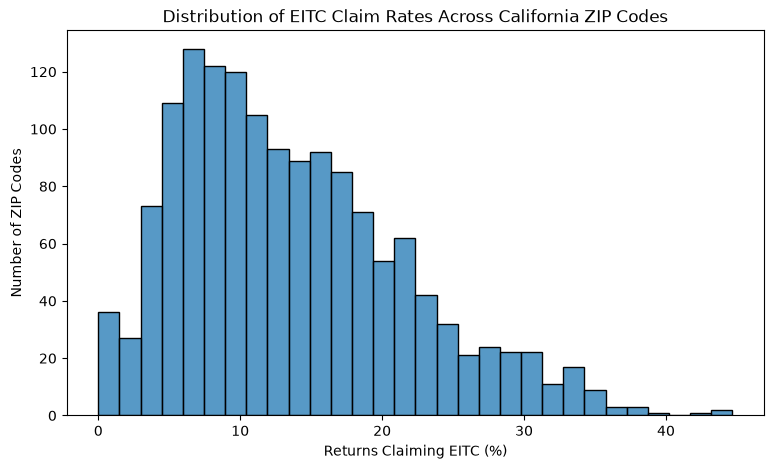

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.histplot(
    data=tax_summary,
    x="eitc_rate",
    bins=30
)

plt.title("Distribution of EITC Claim Rates Across California ZIP Codes")
plt.xlabel("Returns Claiming EITC (%)")
plt.ylabel("Number of ZIP Codes")
plt.show()

In [22]:
processed_path = project_root / "data" / "processed" / "tax_summary.csv"

tax_summary.to_csv(processed_path, index=False)

print("Saved to:", processed_path)

Saved to: /Users/ryangrochol/Desktop/vita access map/data/processed/tax_summary.csv


In [23]:
figures_folder = project_root / "figures"
figures_folder.mkdir(exist_ok=True)

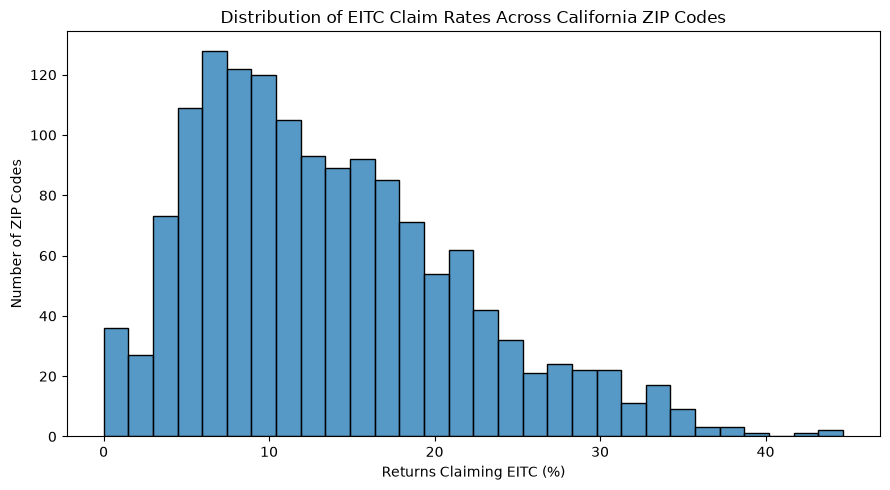

In [24]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=tax_summary,
    x="eitc_rate",
    bins=30
)

plt.title("Distribution of EITC Claim Rates Across California ZIP Codes")
plt.xlabel("Returns Claiming EITC (%)")
plt.ylabel("Number of ZIP Codes")
plt.tight_layout()

plt.savefig(
    figures_folder / "california_eitc_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
alameda_zip_codes = [
    # Alameda
    "94501", "94502",

    # Fremont
    "94536", "94538", "94539", "94555",

    # Hayward and Castro Valley
    "94541", "94542", "94544", "94545", "94546", "94552",

    # Livermore, Pleasanton, Dublin, Newark, and Sunol
    "94550", "94551", "94560", "94566", "94568",
    "94586", "94588",

    # San Leandro, San Lorenzo, and Union City
    "94577", "94578", "94579", "94580", "94587",

    # Oakland
    "94601", "94602", "94603", "94605", "94606",
    "94607", "94608", "94609", "94610", "94611",
    "94612", "94613", "94618", "94619", "94621",

    # Berkeley, Albany, and Emeryville
    "94702", "94703", "94704", "94705", "94706",
    "94707", "94708", "94709", "94710", "94720"
]

In [26]:
alameda_tax = tax_summary[
    tax_summary["zip_code"].isin(alameda_zip_codes)
].copy()

alameda_tax = alameda_tax.sort_values(
    by="eitc_rate",
    ascending=False
).reset_index(drop=True)

print("ZIP codes found:", len(alameda_tax))

alameda_tax[
    ["zip_code", "eitc_rate", "paid_preparer_rate"]
]

ZIP codes found: 47


,zip_code,eitc_rate,paid_preparer_rate
0,94621,24.37037,65.333333
1,94601,20.479705,61.392989
2,94603,20.207927,66.926576
3,94606,18.628031,51.448847
4,94607,16.628176,44.418784
5,94578,15.013405,58.552279
6,94605,14.039534,55.448555
7,94579,11.974978,59.428061
8,94541,11.52719,62.194725
9,94577,11.3876,58.118937


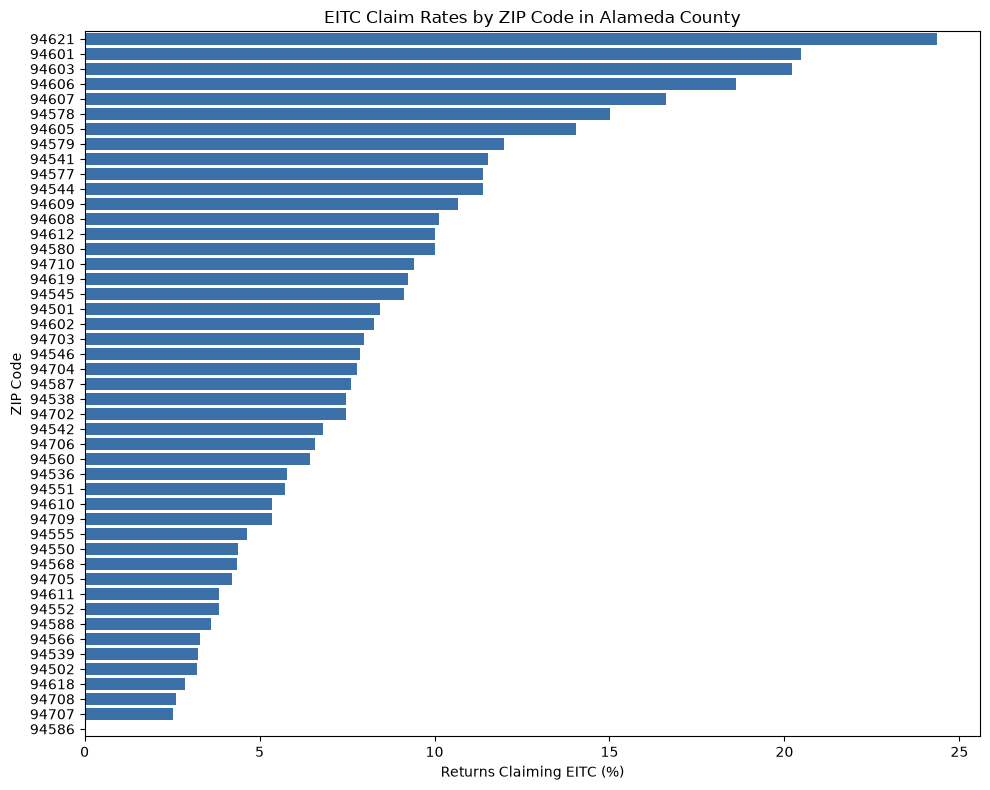

In [27]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=alameda_tax,
    y="zip_code",
    x="eitc_rate",
    color="#2A6FBB"
)

plt.title("EITC Claim Rates by ZIP Code in Alameda County")
plt.xlabel("Returns Claiming EITC (%)")
plt.ylabel("ZIP Code")
plt.tight_layout()

plt.savefig(
    figures_folder / "alameda_eitc_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
alameda_output = (
    project_root
    / "data"
    / "processed"
    / "alameda_tax_summary.csv"
)

alameda_tax.to_csv(alameda_output, index=False)

print("Saved to:", alameda_output)

Saved to: /Users/ryangrochol/Desktop/vita access map/data/processed/alameda_tax_summary.csv


In [29]:
import os
import requests
from dotenv import load_dotenv

load_dotenv(project_root / ".env")

census_api_key = os.getenv("CENSUS_API_KEY")

if census_api_key is None:
    raise ValueError("The Census API key was not found.")

census_url = "https://api.census.gov/data/2022/acs/acs5/profile"

parameters = {
    "get": "NAME,DP03_0128PE,DP02_0072PE",
    "for": "zip code tabulation area:*",
    "key": census_api_key
}

response = requests.get(
    census_url,
    params=parameters,
    timeout=30
)

response.raise_for_status()
census_json = response.json()

print("Rows returned:", len(census_json) - 1)
print("Columns:", census_json[0])

Rows returned: 33774
Columns: ['NAME', 'DP03_0128PE', 'DP02_0072PE', 'zip code tabulation area']


In [30]:
census_data = pd.DataFrame(
    census_json[1:],
    columns=census_json[0]
)

census_data = census_data.rename(columns={
    "zip code tabulation area": "zip_code",
    "DP03_0128PE": "poverty_rate",
    "DP02_0072PE": "disability_rate"
})

census_data["poverty_rate"] = pd.to_numeric(
    census_data["poverty_rate"],
    errors="coerce"
)

census_data["disability_rate"] = pd.to_numeric(
    census_data["disability_rate"],
    errors="coerce"
)

census_data.head()

,NAME,poverty_rate,disability_rate,zip_code
0,ZCTA5 00601,62.2,NaN,00601
1,ZCTA5 00602,47.4,NaN,00602
2,ZCTA5 00603,48.7,NaN,00603
3,ZCTA5 00606,54.0,NaN,00606
4,ZCTA5 00610,45.6,NaN,00610


In [31]:
import numpy as np

census_data.loc[
    census_data["poverty_rate"] < 0,
    "poverty_rate"
] = np.nan

census_data.loc[
    census_data["disability_rate"] < 0,
    "disability_rate"
] = np.nan

In [32]:
alameda_census = census_data[
    census_data["zip_code"].isin(alameda_zip_codes)
].copy()

print("Alameda Census ZIP codes found:", len(alameda_census))

alameda_census[
    ["zip_code", "poverty_rate", "disability_rate"]
].head()

Alameda Census ZIP codes found: 49


,zip_code,poverty_rate,disability_rate
31630,94501,8.2,9.8
31631,94502,2.5,7.2
31659,94536,7.6,7.7
31660,94538,5.0,7.9
31661,94539,3.7,6.1


In [33]:
alameda_combined = alameda_tax.merge(
    alameda_census[
        ["zip_code", "poverty_rate", "disability_rate"]
    ],
    on="zip_code",
    how="left"
)

print("Rows after merge:", len(alameda_combined))

alameda_combined[
    [
        "zip_code",
        "eitc_rate",
        "paid_preparer_rate",
        "poverty_rate",
        "disability_rate"
    ]
].head(10)

Rows after merge: 47


,zip_code,eitc_rate,paid_preparer_rate,poverty_rate,disability_rate
0,94621,24.37037,65.333333,19.9,10.8
1,94601,20.479705,61.392989,18.7,10.5
2,94603,20.207927,66.926576,13.5,11.0
3,94606,18.628031,51.448847,16.7,12.6
4,94607,16.628176,44.418784,19.4,14.2
5,94578,15.013405,58.552279,12.3,11.7
6,94605,14.039534,55.448555,13.1,11.4
7,94579,11.974978,59.428061,8.6,11.9
8,94541,11.52719,62.194725,11.1,12.6
9,94577,11.3876,58.118937,7.2,10.3


In [34]:
alameda_combined[
    alameda_combined["poverty_rate"].isna()
][["zip_code"]]

,zip_code


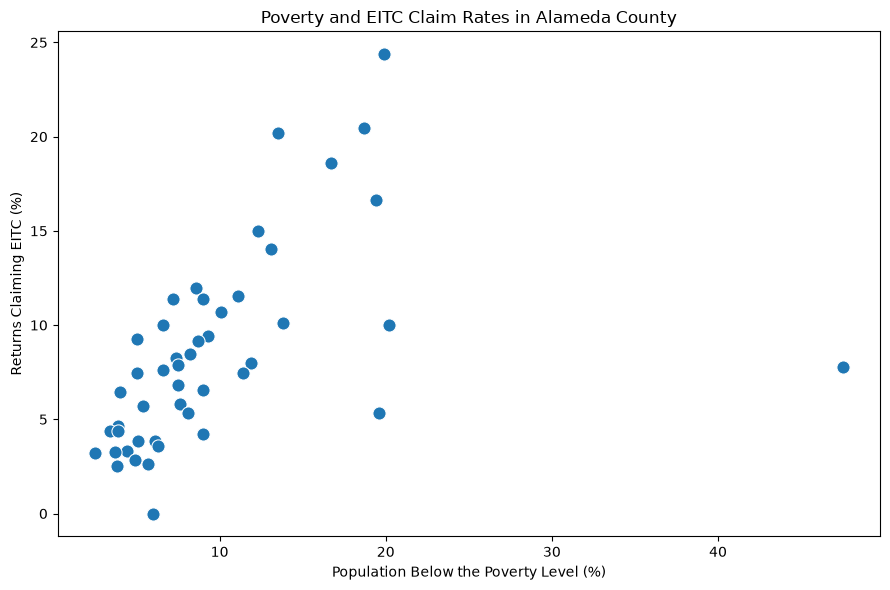

In [35]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=alameda_combined,
    x="poverty_rate",
    y="eitc_rate",
    s=90
)

plt.title("Poverty and EITC Claim Rates in Alameda County")
plt.xlabel("Population Below the Poverty Level (%)")
plt.ylabel("Returns Claiming EITC (%)")
plt.tight_layout()

plt.savefig(
    figures_folder / "poverty_vs_eitc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
correlation = alameda_combined[
    ["poverty_rate", "eitc_rate"]
].corr()

correlation

,poverty_rate,eitc_rate
poverty_rate,1.000000,0.468129
eitc_rate,0.468129,1.000000


In [37]:
combined_output = (
    project_root
    / "data"
    / "processed"
    / "alameda_combined.csv"
)

alameda_combined.to_csv(combined_output, index=False)

print("Saved to:", combined_output)

Saved to: /Users/ryangrochol/Desktop/vita access map/data/processed/alameda_combined.csv


In [43]:
score_data = alameda_combined.dropna(
    subset=["poverty_rate", "disability_rate"]
).copy()

print("ZIP codes available:", len(score_data))

ZIP codes available: 47


In [45]:
from sklearn.preprocessing import StandardScaler

features = [
    "poverty_rate",
    "disability_rate"
]

scaler = StandardScaler()

standardized_values = scaler.fit_transform(
    score_data[features]
)

score_data[
    ["poverty_z", "disability_z"]
] = standardized_values

In [46]:
score_data["preliminary_need_score"] = (
    score_data["poverty_z"]
    + score_data["disability_z"]
) / 2

In [47]:
need_ranking = score_data.sort_values(
    "preliminary_need_score",
    ascending=False
).reset_index(drop=True)

need_ranking[
    [
        "zip_code",
        "poverty_rate",
        "disability_rate",
        "preliminary_need_score"
    ]
].head(10)

,zip_code,poverty_rate,disability_rate,preliminary_need_score
0,94704,47.5,7.6,2.125423
1,94612,20.2,16.2,2.062710
2,94607,19.4,14.2,1.590039
3,94606,16.7,12.6,1.071496
4,94710,9.3,14.5,0.964358
5,94621,19.9,10.8,0.913275
6,94702,11.4,13.4,0.877513
7,94601,18.7,10.5,0.768763
8,94541,11.1,12.6,0.689808
9,94580,6.6,13.9,0.654887


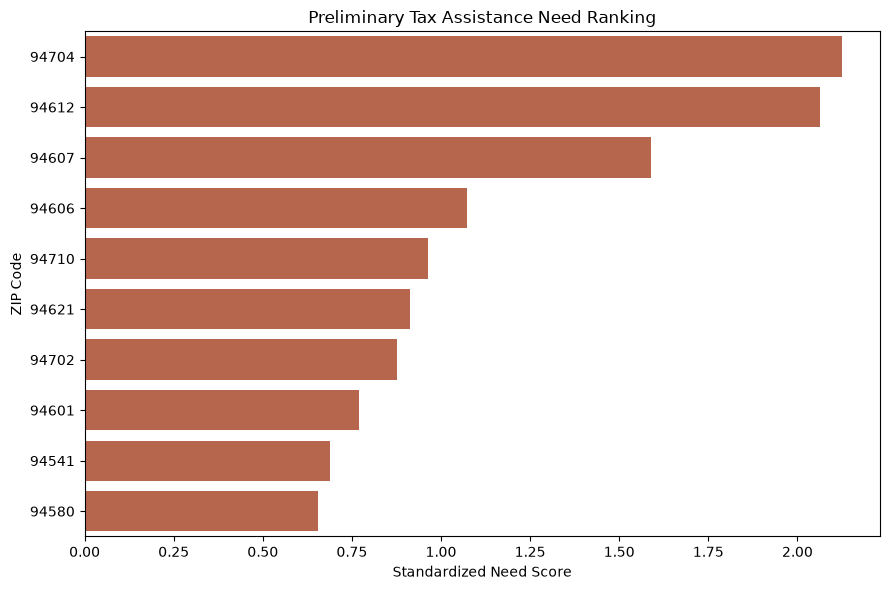

In [48]:
top_10 = need_ranking.head(10)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_10,
    x="preliminary_need_score",
    y="zip_code",
    color="#C65D3B"
)

plt.title("Preliminary Tax Assistance Need Ranking")
plt.xlabel("Standardized Need Score")
plt.ylabel("ZIP Code")
plt.tight_layout()

plt.savefig(
    figures_folder / "preliminary_need_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
need_ranking.to_csv(
    project_root / "data" / "processed" / "preliminary_need_ranking.csv",
    index=False
)

In [51]:
gazetteer_path = (
    project_root
    / "data"
    / "raw"
    / "2022_Gaz_zcta_national.txt"
)

zip_locations = pd.read_csv(
    gazetteer_path,
    sep="\t",
    dtype={"GEOID": str}
)

# Remove extra spaces from Census column names
zip_locations.columns = zip_locations.columns.str.strip()

zip_locations.head()

,GEOID,ALAND,AWATER,ALAND_SQMI,AWATER_SQMI,INTPTLAT,INTPTLONG
0,00601,166848592,798613,64.421,0.308,18.180555,-66.749961
1,00602,78546711,4428428,30.327,1.710,18.361945,-67.175597
2,00603,88980551,6253316,34.356,2.414,18.457399,-67.124867
3,00606,114825641,12228,44.334,0.005,18.158327,-66.932928
4,00610,96150194,4289689,37.124,1.656,18.293960,-67.127182


In [52]:
zip_locations.columns.tolist()

['GEOID',
 'ALAND',
 'AWATER',
 'ALAND_SQMI',
 'AWATER_SQMI',
 'INTPTLAT',
 'INTPTLONG']

In [53]:
zip_locations = zip_locations.rename(columns={
    "GEOID": "zip_code",
    "INTPTLAT": "latitude",
    "INTPTLONG": "longitude"
})

zip_locations = zip_locations[
    ["zip_code", "latitude", "longitude"]
]

zip_locations.head()

,zip_code,latitude,longitude
0,00601,18.180555,-66.749961
1,00602,18.361945,-67.175597
2,00603,18.457399,-67.124867
3,00606,18.158327,-66.932928
4,00610,18.293960,-67.127182


In [54]:
need_ranking = need_ranking.drop(
    columns=["latitude", "longitude", "city"],
    errors="ignore"
)

need_ranking = need_ranking.merge(
    zip_locations,
    on="zip_code",
    how="left"
)

need_ranking[
    [
        "zip_code",
        "latitude",
        "longitude",
        "preliminary_need_score"
    ]
].head()

,zip_code,latitude,longitude,preliminary_need_score
0,94704,37.866417,-122.260922,2.125423
1,94612,37.807709,-122.266857,2.062710
2,94607,37.808842,-122.304697,1.590039
3,94606,37.791366,-122.244513,1.071496
4,94710,37.863923,-122.306465,0.964358


In [55]:
need_ranking[
    need_ranking["latitude"].isna()
][["zip_code"]]

,zip_code


In [56]:
need_ranking.to_csv(
    project_root / "data" / "processed" / "preliminary_need_ranking.csv",
    index=False
)

In [57]:
# Load official Census ZIP-code coordinates
gazetteer_path = (
    project_root
    / "data"
    / "raw"
    / "2022_Gaz_zcta_national.txt"
)

zip_locations = pd.read_csv(
    gazetteer_path,
    sep="\t",
    dtype=str
)

# Remove extra spaces from the column names
zip_locations.columns = zip_locations.columns.str.strip()

# Rename the columns we need
zip_locations = zip_locations.rename(columns={
    "GEOID": "zip_code",
    "INTPTLAT": "latitude",
    "INTPTLONG": "longitude"
})

# Keep only ZIP code and coordinates
zip_locations = zip_locations[
    ["zip_code", "latitude", "longitude"]
].copy()

# Convert coordinates to numbers
zip_locations["latitude"] = pd.to_numeric(
    zip_locations["latitude"],
    errors="coerce"
)

zip_locations["longitude"] = pd.to_numeric(
    zip_locations["longitude"],
    errors="coerce"
)

# Remove any failed coordinates from previous attempts
need_ranking = need_ranking.drop(
    columns=["latitude", "longitude", "city"],
    errors="ignore"
)

# Add the Census coordinates to the need-ranking table
need_ranking = need_ranking.merge(
    zip_locations,
    on="zip_code",
    how="left"
)

# Save the updated data for the Streamlit app
need_ranking.to_csv(
    project_root
    / "data"
    / "processed"
    / "preliminary_need_ranking.csv",
    index=False
)

# Display the result
need_ranking[
    [
        "zip_code",
        "poverty_rate",
        "disability_rate",
        "preliminary_need_score",
        "latitude",
        "longitude"
    ]
].head(10)

,zip_code,poverty_rate,disability_rate,preliminary_need_score,latitude,longitude
0,94704,47.5,7.6,2.125423,37.866417,-122.260922
1,94612,20.2,16.2,2.062710,37.807709,-122.266857
2,94607,19.4,14.2,1.590039,37.808842,-122.304697
3,94606,16.7,12.6,1.071496,37.791366,-122.244513
4,94710,9.3,14.5,0.964358,37.863923,-122.306465
5,94621,19.9,10.8,0.913275,37.751130,-122.210178
6,94702,11.4,13.4,0.877513,37.866321,-122.286348
7,94601,18.7,10.5,0.768763,37.775760,-122.218572
8,94541,11.1,12.6,0.689808,37.673757,-122.087823
9,94580,6.6,13.9,0.654887,37.678001,-122.133367


In [58]:
city_lookup = {
    "94501": "Alameda",
    "94502": "Alameda",

    "94536": "Fremont",
    "94538": "Fremont",
    "94539": "Fremont",
    "94555": "Fremont",

    "94541": "Hayward",
    "94542": "Hayward",
    "94544": "Hayward",
    "94545": "Hayward",
    "94546": "Castro Valley",
    "94552": "Castro Valley / Hayward",

    "94550": "Livermore",
    "94551": "Livermore",
    "94560": "Newark",
    "94566": "Pleasanton",
    "94568": "Dublin",
    "94586": "Sunol",
    "94588": "Pleasanton",

    "94577": "San Leandro",
    "94578": "San Leandro",
    "94579": "San Leandro",
    "94580": "San Lorenzo",
    "94587": "Union City",

    "94601": "Oakland",
    "94602": "Oakland",
    "94603": "Oakland",
    "94605": "Oakland",
    "94606": "Oakland",
    "94607": "Oakland",
    "94608": "Emeryville / Oakland",
    "94609": "Oakland",
    "94610": "Oakland",
    "94611": "Oakland",
    "94612": "Oakland",
    "94613": "Oakland",
    "94618": "Oakland",
    "94619": "Oakland",
    "94621": "Oakland",

    "94702": "Berkeley",
    "94703": "Berkeley",
    "94704": "Berkeley",
    "94705": "Berkeley",
    "94706": "Albany",
    "94707": "Berkeley",
    "94708": "Berkeley",
    "94709": "Berkeley",
    "94710": "Berkeley",
    "94720": "Berkeley"
}

need_ranking["city"] = (
    need_ranking["zip_code"]
    .map(city_lookup)
    .fillna("Unknown")
)

need_ranking["location"] = (
    need_ranking["city"]
    + " ("
    + need_ranking["zip_code"]
    + ")"
)

need_ranking[
    [
        "zip_code",
        "city",
        "location",
        "preliminary_need_score"
    ]
].head(10)

,zip_code,city,location,preliminary_need_score
0,94704,Berkeley,Berkeley (94704),2.125423
1,94612,Oakland,Oakland (94612),2.062710
2,94607,Oakland,Oakland (94607),1.590039
3,94606,Oakland,Oakland (94606),1.071496
4,94710,Berkeley,Berkeley (94710),0.964358
5,94621,Oakland,Oakland (94621),0.913275
6,94702,Berkeley,Berkeley (94702),0.877513
7,94601,Oakland,Oakland (94601),0.768763
8,94541,Hayward,Hayward (94541),0.689808
9,94580,San Lorenzo,San Lorenzo (94580),0.654887


In [59]:
need_ranking.to_csv(
    project_root
    / "data"
    / "processed"
    / "preliminary_need_ranking.csv",
    index=False
)

In [60]:
city_groups = {
    "Alameda": [
        "94501", "94502"
    ],
    "Fremont": [
        "94536", "94538", "94539", "94555"
    ],
    "Hayward": [
        "94541", "94542", "94544", "94545"
    ],
    "Castro Valley": [
        "94546"
    ],
    "Castro Valley / Hayward": [
        "94552"
    ],
    "Livermore": [
        "94550", "94551"
    ],
    "Newark": [
        "94560"
    ],
    "Pleasanton": [
        "94566", "94588"
    ],
    "Dublin": [
        "94568"
    ],
    "Sunol": [
        "94586"
    ],
    "San Leandro": [
        "94577", "94578", "94579"
    ],
    "San Lorenzo": [
        "94580"
    ],
    "Union City": [
        "94587"
    ],
    "Oakland": [
        "94601", "94602", "94603", "94605", "94606",
        "94607", "94609", "94610", "94611", "94612",
        "94613", "94618", "94619", "94621"
    ],
    "Emeryville / Oakland": [
        "94608"
    ],
    "Berkeley": [
        "94702", "94703", "94704", "94705", "94707",
        "94708", "94709", "94710", "94720"
    ],
    "Albany": [
        "94706"
    ]
}

city_lookup = {
    zip_code: city
    for city, zip_codes in city_groups.items()
    for zip_code in zip_codes
}

need_ranking["city"] = (
    need_ranking["zip_code"]
    .map(city_lookup)
    .fillna("Unknown")
)

need_ranking["location"] = (
    need_ranking["city"]
    + " ("
    + need_ranking["zip_code"]
    + ")"
)

need_ranking.to_csv(
    project_root
    / "data"
    / "processed"
    / "preliminary_need_ranking.csv",
    index=False
)

need_ranking[
    ["zip_code", "city", "location"]
].head(10)

,zip_code,city,location
0,94704,Berkeley,Berkeley (94704)
1,94612,Oakland,Oakland (94612)
2,94607,Oakland,Oakland (94607)
3,94606,Oakland,Oakland (94606)
4,94710,Berkeley,Berkeley (94710)
5,94621,Oakland,Oakland (94621)
6,94702,Berkeley,Berkeley (94702)
7,94601,Oakland,Oakland (94601)
8,94541,Hayward,Hayward (94541)
9,94580,San Lorenzo,San Lorenzo (94580)
